# Example 6.1: State-space modal analysis



## Two coupled masses

<center>
<img src="figures/Mass_spring_nonprop_damp.svg">
</center>

Each mass has $m=1\,\mathrm{kg}$ and is connected to ground by a spring with stiffness $k_g=100\,\mathrm{N/m}$. A weaker spring with $k_c=30\,\mathrm{N/m}$ connects the masses.

$$\mathbf M=\begin{bmatrix}m&0\\0&m\end{bmatrix},\qquad
\mathbf K=\begin{bmatrix}k_g+k_c&-k_c\\-k_c&k_g+k_c\end{bmatrix}.$$

We will explore to alternatives for damping:

- Rayleigh damping (aka. proportional damping)
- A single ground damper on mass 1, with $c=2\,\mathrm{N\,s/m}$, (aka. non-proportional damping)
  

## Mass and stiffness


In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import linalg as spla
np.set_printoptions(precision=3, suppress=True)

m = 1.0  # Each mass [kg]
k_g = 100.0  # Each ground spring [N/m]
k_c = 30.0  # Coupling spring [N/m]
M = m*np.eye(2)
K = np.array([[k_g+k_c, -k_c], [-k_c, k_g+k_c]])

We still use the equation of motion:
$$
\mathbf{M} \mathbf{\ddot{u}}(t) + 
\mathbf{C} \mathbf{\dot{u}}(t) + 
\mathbf{K} \mathbf{{u}}(t) =
\mathbf{f}(t)
$$

In this example, we will look at different types of damping models, and how they affect the calculation of damping ratios and mode shapes.

## Proportionally damped system

We will first assign a Rayleigh damping matrix:

$$\mathbf{C}=\alpha_1 \mathbf{M}+\alpha_2 \mathbf{K}$$

We solve the undamped eigenvalue problem, where only mass and stiffness are considered:

$$
\mathbf{M} \mathbf{\ddot{u}}(t) + 
\mathbf{K} \mathbf{{u}}(t) =
\mathbf{0}
$$

We assume that the homogeneous solution of the differential equation is $ \mathbf{u} = \boldsymbol{\phi}e^{\lambda t}  $, which we insert into the equations to obtain the undamped eigenvalue problem:

$$\left( \lambda^2\mathbf{M}+\mathbf{K} \right)  \boldsymbol{\phi} = \mathbf{0}   $$


Here, it can be shown that the eigenvalues are purely imaginary, $\lambda=\pm i \omega_n$, where $\omega_n$ are the undamped natural frequencies. $ \boldsymbol{\phi}$ is the mode shape vector.

With Rayleigh damping, the undamped eigenvectors also uncouple the damped equations. Damping changes the eigenvalues, but the displacement mode shapes can still be chosen real.

In [2]:
alpha1 = 0.4  # [1/s]
alpha2 = 0.003  # [s]
C = alpha1*M + alpha2*K

omega_squared, Phi = spla.eigh(K, M)  # Sorted, mass-normalized modes
omega_n = np.sqrt(omega_squared)

print('Undamped natural frequencies [rad/s]:', omega_n)
print('Mass-normalized mode shapes (columns):\n', Phi)
print('Rayleigh damping ratios [%]:', 100*(alpha1+alpha2*omega_squared)/(2*omega_n))

Undamped natural frequencies [rad/s]: [10.    12.649]
Mass-normalized mode shapes (columns):
 [[-0.707 -0.707]
 [-0.707  0.707]]
Rayleigh damping ratios [%]: [3.5   3.479]


In [3]:
# Print modal matrices
print('M_modal=')
print(Phi.T @ M @ Phi)

print('C_modal=')
print(Phi.T @ C @ Phi)


print('K_modal=')
print(Phi.T @ K @ Phi)


M_modal=
[[1. 0.]
 [0. 1.]]
C_modal=
[[0.7  0.  ]
 [0.   0.88]]
K_modal=
[[100.   0.]
 [  0. 160.]]


We know that the mode shape matrix from the (undamped) eigenvalue problem will make the modal mass and stiffness matrices diagonal:

$$\mathbf{\Phi}^\text{T} \mathbf{M} \mathbf{\Phi} = \tilde{\mathbf{M}}= \text{diag}(\tilde{m}_1,\tilde{m}_2,\dots)$$


$$\mathbf{\Phi}^\text{T} \mathbf{K} \mathbf{\Phi} = \tilde{\mathbf{K}}= \text{diag}(\tilde{k}_1,\tilde{k}_2,\dots)$$


In the case of Rayleigh damping, it is easy to show that the modal damping matrix will also be diagonal:

$$\tilde{\mathbf{C}} = \mathbf{\Phi}^\text{T} \mathbf{C} \mathbf{\Phi} =
\mathbf{\Phi}^\text{T} (\alpha_1 \mathbf{M}+\alpha_2 \mathbf{K}) \mathbf{\Phi} =
\alpha_1  \tilde{\mathbf{M}}
+ 
\alpha_2  \tilde{\mathbf{K}}
$$

The Rayleigh damping is therefore an example of *proportional damping* or *classical damping*. The modes obtained from the undamped eigenvalue problem therefore fully uncouple the equations of motion. 


Structural damping is something we rarely directly control as engineers. What if the system does not have proportional damping? This will be explored in the following.


## Animation of mode shapes

In [4]:
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Rectangle
from IPython.display import HTML

def spring(xa, xb, y):
    x = np.linspace(xa, xb, 19)
    z = np.zeros(19)
    z[2:-2] = 0.10*(-1.0)**np.arange(15)
    return x, y+z

def animate_modes(shapes, frequencies, heading, mode_idx=0):
    """Animate one mode; mode_idx is zero-based (0 = first mode)."""
    if not isinstance(mode_idx, (int, np.integer)) or not 0 <= mode_idx < shapes.shape[1]:
        raise ValueError('mode_idx must be a valid zero-based mode index')
    shapes = shapes[:, mode_idx:mode_idx+1].astype(complex).copy()
    frequencies = np.asarray(frequencies)[mode_idx:mode_idx+1]
    shapes *= np.exp(-1j*np.angle(shapes[0, :]))
    shapes /= np.max(np.abs(shapes), axis=0)
    fig, axes = plt.subplots(1, 1, figsize=(9, 2.8), squeeze=False)
    artists = []
    for j, ax in enumerate(axes.flat):
        ax.set(xlim=(-0.3, 8.3), ylim=(-0.9, 0.8), yticks=[])
        ax.set_title(f'{heading}: mode {mode_idx+1}')
        ax.axvline(0, color='black'); ax.axvline(8, color='black')
        blocks = [Rectangle((x-0.3,-0.25),0.6,0.5, color=color) for x,color in [(2.5,'tab:blue'),(5.5,'tab:orange')]]
        for block in blocks: ax.add_patch(block)
        springs = [ax.plot([],[],color='0.35')[0] for _ in range(3)]
        labels = [ax.text(x,0,'m'+str(i+1),ha='center',va='center',color='white') for i,x in enumerate([2.5,5.5])]
        artists.append((blocks,springs,labels))
    fig.tight_layout()
    def update(t):
        for j,(blocks,springs,labels) in enumerate(artists):
            pos=np.array([2.5,5.5])+0.65*np.real(shapes[:,j]*np.exp(1j*frequencies[j]*t))
            for i in range(2):
                blocks[i].set_x(pos[i]-0.3); labels[i].set_x(pos[i])
            for line,(a,b) in zip(springs,[(0,pos[0]-0.3),(pos[0]+0.3,pos[1]-0.3),(pos[1]+0.3,8)]):
                line.set_data(*spring(a,b,0))
        return []
    ani=FuncAnimation(fig,update,frames=np.linspace(0,4*2*np.pi/min(frequencies),120,endpoint=False),interval=50)
    plt.close(fig)
    return HTML(ani.to_jshtml())

animate_modes(Phi, omega_n, 'Undamped / proportional mode shape', mode_idx=1)

## Non-proportional damping

We now replace Rayleigh damping with a single damper connected between mass 1 and ground:

$$\mathbf C=\begin{bmatrix}c&0\\0&0\end{bmatrix},\qquad c=2\,\mathrm{N\,s/m}.$$

The undamped modes still diagonalize $\mathbf M$ and $\mathbf K$, but do not diagonalize this damping matrix. The off-diagonal modal damping terms couple the two closely spaced modes.

We confirm below that the modes from the undamped eigenvalue problem do not diagonalize $\mathbf C$.


In [5]:
c = 2.0  # Ground damper on mass 1 [N s/m]
C = np.diag([c, 0.0])
print('C_modal=')
print(Phi.T @ C @ Phi)


C_modal=
[[1. 1.]
 [1. 1.]]


We want to calculate the damping ratios of the structure, and we can not neglect the damping when solving the eigenvalue problem. We still assume that the homogeneous solution of the differential equation has the following form:

$$ \mathbf{u} = \boldsymbol{\phi}e^{\lambda t}  $$

We further insert this solution into the differential equation to obtain the *quadratic eigenvalue problem* or *damped eigenvalue problem*:

$$\left( \lambda^2\mathbf{M} + \lambda \mathbf{C} +\mathbf{K} \right)\boldsymbol{\phi} = \mathbf{0}   $$

The eigenvalues come in complex conjugate pairs $\lambda = a \pm ib$, and the corresponding eigenvectors also come in complex conjugate pairs. This is to ensure that the sum of the imaginary parts is zero such that the dynamic response is real. A complex solution associated with one eigenpair is

$$ \mathbf{u} = \boldsymbol{\phi} e^{\lambda t} = \boldsymbol{\phi} e^{at}\left( \cos (bt) + i \sin(bt) \right)  $$

The physical modal motion is its real part, $\Re(\boldsymbol{\phi}e^{\lambda t})$. Its scalar time dependence corresponds to the free vibration response of a damped single degree of freedom system:

$$ u(t) = e^{-\zeta \omega_n t}\left( C_1\cos (\omega_D t) + C_2 \sin(\omega_D t) \right)  $$


The eigenvalue can thus be defined as 

$$\lambda = -\zeta \omega_n \pm i \omega_D=-\zeta \omega_n \pm i \omega_n\sqrt{1-\zeta^2}$$

For each oscillatory eigenpair, define the modal frequency parameter as 

$$\omega_n = |\lambda|$$

For non-proportional damping, this parameter need not equal a natural frequency of the undamped system. The damped oscillation frequency is $|\Im(\lambda)|$, and the damping ratio is minus the real part divided by the absolute value of the eigenvalue:

$$\zeta = -\Re(\lambda)/ |\lambda| $$

It is convenient to avoid solving the quadratic eigenvalue problem by transforming the system of second-order differential equations to a system of first-order differential equations. This is often referred to as transforming the system to state-space. Note that there are no approximations involved in this transform.

$$ \ddot{\mathbf{u}} + \mathbf{M}^{-1} \mathbf{C} \dot{\mathbf{u}} +\mathbf{M}^{-1} \mathbf{K} \mathbf{u} = \mathbf{M}^{-1}  \mathbf{f}(t)    $$

$$ \left[ \begin{array}{c} \dot{\mathbf{u}}\\ \ddot{\mathbf{u}} \end{array} \right] 
+ \left[ \begin{array}{c} \mathbf{0}& -\mathbf{I} \\ \mathbf{M}^{-1} \mathbf{K} & \mathbf{M}^{-1} \mathbf{C} \end{array} \right] 
\left[ \begin{array}{c} \mathbf{u}\\ \dot{\mathbf{u}} \end{array} \right] 
= \left[ \begin{array}{c} \mathbf{0}\\ \mathbf{M}^{-1}  \end{array} \right]   \mathbf{f}(t) $$

The system can then be represented by the state vector $\mathbf{x}=\left[ \begin {array}{cc} \mathbf{u} & \dot{\mathbf{u}} \end{array}\right]^\text{T}$ and the system of first order differential equations reads

$$ \dot{\mathbf{x}} = \mathbf{A}\mathbf{x} + \mathbf{B}\mathbf{f}(t)   $$

$$\mathbf{A} = \left[ {\begin{array}{c} {\mathbf{0}}&{\mathbf{I}}\\ {-\mathbf{M}^{-1} \mathbf{K}}&{-\mathbf{M}^{-1} \mathbf{C}} \end{array}} \right]  
,
\quad
\mathbf{B} = \left[ \begin{array}{c} \mathbf{0} \\ \mathbf{M}^{-1} \end{array} \right]   $$

Assuming once again that the solution is of the form 

$$ \mathbf{u} = \boldsymbol{\phi} e^{\lambda t}  $$

The eigenvalue problem reads

$$
\mathbf{A} \boldsymbol{\psi}
= \lambda \boldsymbol{\psi}
$$

where the eigenvector $ \boldsymbol{\psi}$ contains the mode shape vector $\boldsymbol{\phi}$ and  $\lambda \boldsymbol{\phi}$:

$$
 \boldsymbol{\psi} = \left[ \begin{array}{c} 
\boldsymbol{\phi} \\
\lambda \boldsymbol{\phi}
\end{array} \right]
$$

In [6]:
A = np.block([[np.zeros_like(M), np.eye(2)],
              [-np.linalg.solve(M, K), -np.linalg.solve(M, C)]])
lamb, psi = spla.eig(A)
order = np.argsort(np.abs(lamb), kind="stable")  # Increasing natural frequency
lamb = lamb[order]
psi = psi[:, order]
omega_n_ss = np.abs(lamb)
zeta = -lamb.real/omega_n_ss

print('Eigenvalues:', lamb)
print('Natural frequencies |lambda| [rad/s]:', omega_n_ss)
print('Damping ratios [%]:', 100*zeta)
print('Complex displacement mode shapes (columns):\n', psi[:2, :])


Eigenvalues: [-0.509+10.074j -0.509-10.074j -0.491+12.53j  -0.491-12.53j ]
Natural frequencies |lambda| [rad/s]: [10.087 10.087 12.54  12.54 ]
Damping ratios [%]: [5.046 5.046 3.915 3.915]
Complex displacement mode shapes (columns):
 [[-0.004-0.07j  -0.004+0.07j   0.021-0.051j  0.021+0.051j]
 [ 0.02 -0.066j  0.02 +0.066j  0.002+0.057j  0.002-0.057j]]


## Animation of complex mode shapes

Both masses now move with different phases within each mode. The relative phase is $\arg(\phi_2/\phi_1)$. The values are approximately $19.6^\circ$ and $155.3^\circ$, compared with $0^\circ$ and $180^\circ$ for the undamped modes.

The animation shows $\Re(\boldsymbol\phi e^{i\omega_Dt})$: the decay envelope is deliberately omitted so that the phase difference remains visible.

In [7]:
# Use one mode from each conjugate pair for the animations and time traces.
mode_indices = np.flatnonzero(lamb.imag > 0)
mode_indices = mode_indices[np.argsort(lamb[mode_indices].imag)]
lambda_modes = lamb[mode_indices]
complex_modes = psi[:2, mode_indices].copy()
complex_modes *= np.exp(-1j*np.angle(complex_modes[0, :]))
complex_modes /= np.max(np.abs(complex_modes), axis=0)

animate_modes(complex_modes, lambda_modes.imag, 'Non-proportional mode shape', mode_idx=1)


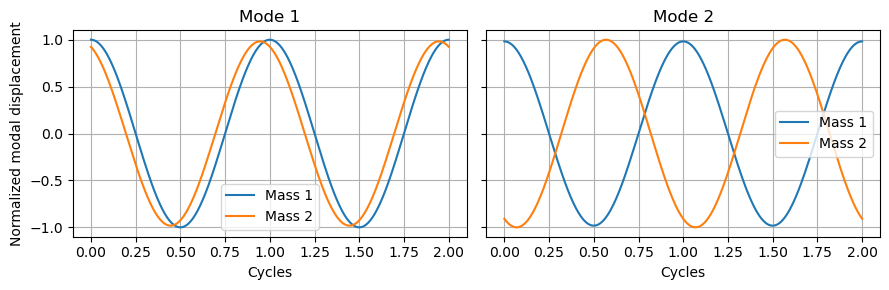

In [8]:
# Time traces make the relative phases easier to compare.
fig, axes = plt.subplots(1, 2, figsize=(9, 3), sharey=True)
for j, ax in enumerate(axes):
    cycles = np.linspace(0, 2, 400)
    motion = np.real(complex_modes[:,j,None]*np.exp(2j*np.pi*cycles))
    ax.plot(cycles,motion[0],label='Mass 1')
    ax.plot(cycles,motion[1],label='Mass 2')
    ax.set(xlabel='Cycles', title=f'Mode {j+1}')
    ax.grid(True); ax.legend()
axes[0].set_ylabel('Normalized modal displacement')
fig.tight_layout()